In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error as mae

from math import sqrt
from statsforecast.models import AutoARIMA, AutoETS
from statsforecast import StatsForecast
import matplotlib.pyplot as plt
from prophet import Prophet


data = pd.read_csv('C:/Users/LENOVO/Documents/python_data_analytics_course/Pod 2 Project/era_5_2000_2026.csv')

c:\Users\LENOVO\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


DATA CLEANING, PREPROCESSING AND FEATURE ENGINEERING

In [2]:
#Convert data to datetime object and create new columns for month and year

data['date'] = pd.to_datetime(data['date'])
data['year'] = data['date'].dt.year

data.head()

,date,tp,cin,zust,dndzn,dndza,dctb,tplb,tplt,cbh,...,stl4,tsn,fal,fsr,flsr,u100,v100,extreme_rain,extreme_temp,year
0,2000-01-01,0.003093,0.00000,0.103641,-0.574058,-0.595149,56.145935,64.626300,88.544510,5339.7650,...,300.73694,273.06628,0.148892,1.179369,-2.680056,-0.198515,-0.747013,0,0,2000
1,2000-02-01,0.000717,0.00000,0.121184,-0.751629,-0.765809,15.207466,19.881092,34.173347,9409.0820,...,301.06610,273.13342,0.165629,1.179371,-2.680512,-1.101938,-2.731149,0,0,2000
2,2000-03-01,0.129755,595.18677,0.124302,-0.574855,-0.590825,106.652600,120.659030,149.928120,5690.5996,...,301.41320,273.11118,0.179476,1.179329,-2.679310,-0.194799,-0.071353,0,0,2000
3,2000-04-01,0.626420,548.91180,0.159593,-0.640003,-0.642903,189.395870,202.430880,230.885560,2821.8843,...,302.54883,273.11206,0.186002,1.179013,-2.677608,1.265121,2.993181,0,0,2000
4,2000-05-01,2.711060,354.53662,0.142898,-0.780991,-0.783585,108.679290,114.388000,129.806230,1907.0151,...,303.51605,273.07294,0.186361,1.177660,-2.668397,1.196867,2.766333,0,0,2000


DATA SPLITTING

In [3]:
temp_data = data[['t2m', 'date', 'year']].copy()
temp_data['unique_id'] = 'temp'

temp_train = temp_data[temp_data['year'] <= 2023].copy()
temp_train.drop(columns=['year'], axis = 1, inplace= True)

temp_test = temp_data[temp_data['year'] > 2023].copy()
temp_test.drop(columns=['year'], axis = 1, inplace= True)

temp_train

,t2m,date,unique_id
0,28.86465,2000-01-01,temp
1,28.01006,2000-02-01,temp
2,30.63613,2000-03-01,temp
3,31.49660,2000-04-01,temp
4,30.10635,2000-05-01,temp
...,...,...,...
283,26.92230,2023-08-01,temp
284,27.40160,2023-09-01,temp
285,28.62800,2023-10-01,temp
286,29.60214,2023-11-01,temp


COLUMN REFORMATTING TO STATSFORECAST FORMAT

In [7]:
temp_train = temp_train.rename(columns={
    'date':'ds',
    't2m':'y'
})

temp_test = temp_test.rename(columns={
    'date':'ds',
    't2m':'y'
})

temp_train

,y,ds,unique_id
0,28.86465,2000-01-01,temp
1,28.01006,2000-02-01,temp
2,30.63613,2000-03-01,temp
3,31.49660,2000-04-01,temp
4,30.10635,2000-05-01,temp
...,...,...,...
283,26.92230,2023-08-01,temp
284,27.40160,2023-09-01,temp
285,28.62800,2023-10-01,temp
286,29.60214,2023-11-01,temp


In [8]:
temp_test

,y,ds,unique_id
288,28.12400,2024-01-01,temp
289,30.55250,2024-02-01,temp
290,33.31716,2024-03-01,temp
291,32.61800,2024-04-01,temp
292,31.29226,2024-05-01,temp
293,29.07090,2024-06-01,temp
294,27.29990,2024-07-01,temp
295,27.13757,2024-08-01,temp
296,27.33602,2024-09-01,temp
297,27.92910,2024-10-01,temp


In [9]:
freq = pd.infer_freq(temp_train.ds)

freq

'MS'

TRAINING
- SARIMA
- AUTOETS
- PROPHET

SARIMA

In [12]:
temp_sarima = AutoARIMA(season_length=12, alias = 'SARIMA')
temp_ets = AutoETS(season_length=12, alias = 'ETS')
temp_sf = StatsForecast(models = [temp_sarima, temp_ets], freq = 'MS')
temp_sf.fit(temp_train)
temp_pred = temp_sf.predict(h = 24)

temp_pred.head()

,unique_id,ds,SARIMA,ETS
0,temp,2024-01-01,28.115853,28.344488
1,temp,2024-02-01,30.003103,30.676082
2,temp,2024-03-01,31.868427,32.328008
3,temp,2024-04-01,31.596774,31.724541
4,temp,2024-05-01,30.018552,30.123670


In [13]:
temp_df = temp_pred
temp_test.reset_index(inplace = True)
temp_df['Actual'] = temp_test.y

temp_df

,unique_id,ds,SARIMA,ETS,Actual
0,temp,2024-01-01,28.115853,28.344488,28.12400
1,temp,2024-02-01,30.003103,30.676082,30.55250
2,temp,2024-03-01,31.868427,32.328008,33.31716
3,temp,2024-04-01,31.596774,31.724541,32.61800
4,temp,2024-05-01,30.018552,30.123670,31.29226
5,temp,2024-06-01,27.913877,28.103032,29.07090
6,temp,2024-07-01,26.870967,26.991112,27.29990
7,temp,2024-08-01,26.228118,26.338275,27.13757
8,temp,2024-09-01,26.517633,26.760268,27.33602
9,temp,2024-10-01,27.719920,27.836634,27.92910


In [14]:
temp_sarima_mae = mae(temp_df['Actual'], temp_df['SARIMA'])
temp_ets_mae = mae(temp_df['Actual'], temp_df['ETS'])
temp_sarima_mae, temp_ets_mae

(0.7172711598445174, 0.49750104972538445)

PROPHET

In [15]:
temp_train.drop('unique_id', axis = 1, inplace=True)
temp_train

,y,ds
0,28.86465,2000-01-01
1,28.01006,2000-02-01
2,30.63613,2000-03-01
3,31.49660,2000-04-01
4,30.10635,2000-05-01
...,...,...
283,26.92230,2023-08-01
284,27.40160,2023-09-01
285,28.62800,2023-10-01
286,29.60214,2023-11-01


In [21]:
model = Prophet(
    yearly_seasonality= True,
    weekly_seasonality = False,
    daily_seasonality = False,
    seasonality_mode = 'additive'
)
model.fit(temp_train)

temp_future = model.make_future_dataframe(periods = 25, freq = 'M')
temp_forecast = model.predict(temp_future)

temp_yhat = temp_forecast[['yhat']].tail(24).reset_index(drop = True)

temp_df['Prophet'] = temp_yhat
temp_df

03:38:36 - cmdstanpy - INFO - Chain [1] start processing
03:38:36 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\LENOVO\anaconda3\envs\python_course\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,unique_id,ds,SARIMA,ETS,Actual,Prophet
0,temp,2024-01-01,28.115853,28.344488,28.12400,30.373242
1,temp,2024-02-01,30.003103,30.676082,30.55250,32.305642
2,temp,2024-03-01,31.868427,32.328008,33.31716,31.533068
3,temp,2024-04-01,31.596774,31.724541,32.61800,30.050557
4,temp,2024-05-01,30.018552,30.123670,31.29226,27.716169
5,temp,2024-06-01,27.913877,28.103032,29.07090,26.997926
6,temp,2024-07-01,26.870967,26.991112,27.29990,26.149663
7,temp,2024-08-01,26.228118,26.338275,27.13757,26.775575
8,temp,2024-09-01,26.517633,26.760268,27.33602,27.901906
9,temp,2024-10-01,27.719920,27.836634,27.92910,29.149801


In [22]:
temp_df.columns

Index(['unique_id', 'ds', 'SARIMA', 'ETS', 'Actual', 'Prophet'], dtype='object')

<Axes: title={'center': 'Forecast Comparison'}>

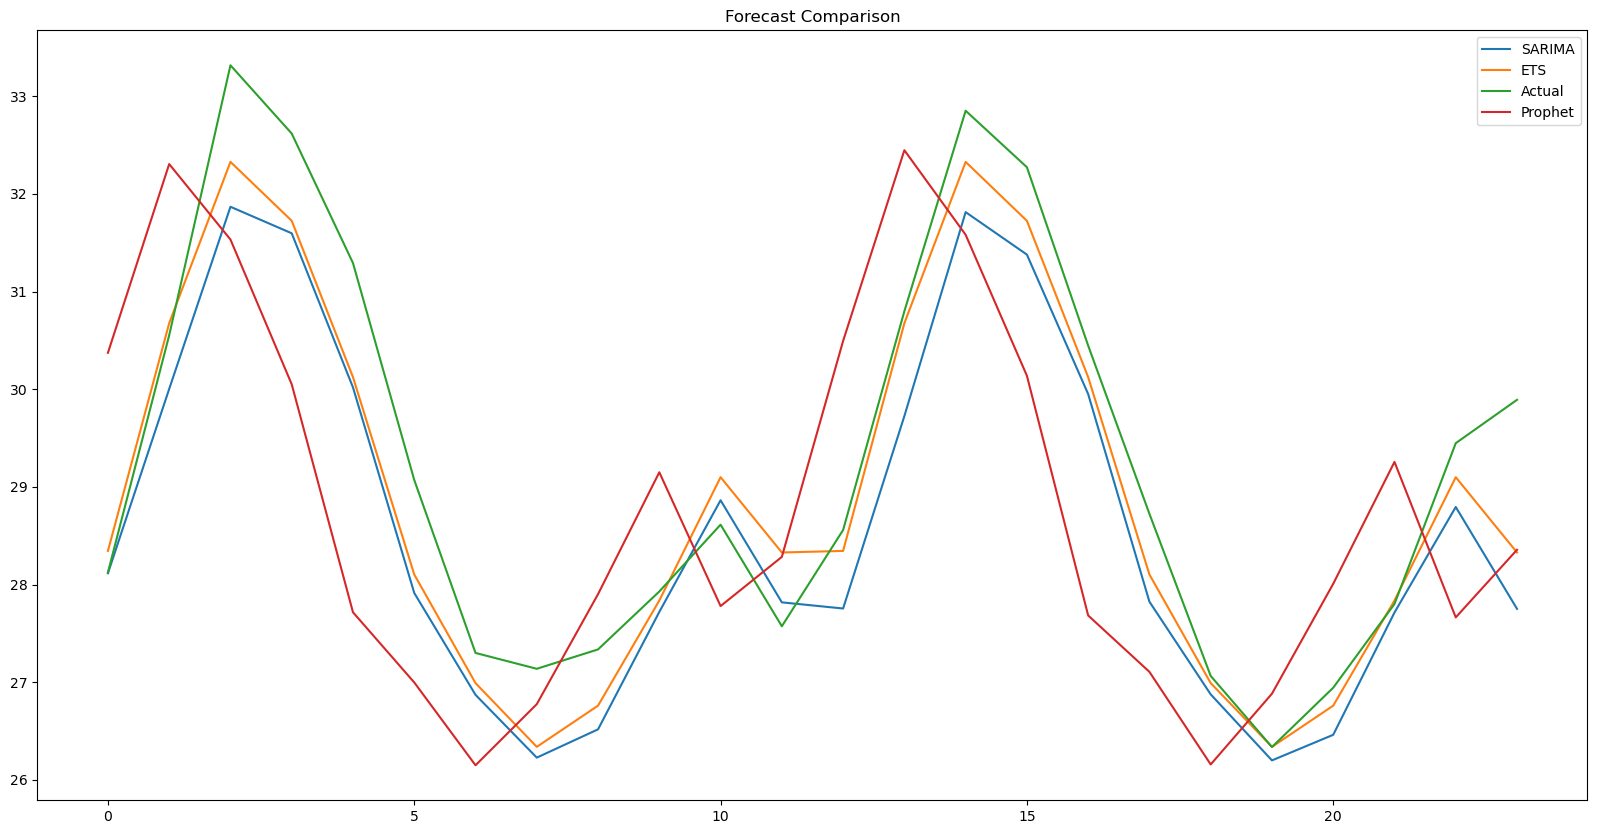

In [23]:
temp_df[['SARIMA', 'ETS', 'Actual', 'Prophet']].plot(kind = 'line', figsize=(20, 10),
    title='Forecast Comparison')